# Config

In [1]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

import numpy as np

# 1. Define the Ordinal Mapping
# We map 'Always' to 4 and 'Never' to 1 so that 'higher' means more safe.
usage_map = {
    "Always": 4,
    "Most times": 3,
    "Sometimes": 2,
    "Never": 1
}

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from plots import plot_satisfaction_bar, plot_target_correlations, analyze_ppe_usage, usage_summary
from correlations import plot_lower_triangle_heatmap, plot_target_correlation, calculate_spearman_correlation, calculate_binary_correlation
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [2]:
file_path = RAW_DATA_DIR / "FCTAES_279691_TOTAL_20251006.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

labels_df = pd.read_excel(file_path, sheet_name="Labels")
print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 514)
Labels (1813, 514)
Variables (515, 4)


# Data processing

In [3]:
# -------------------------------
# Filter rows: motorcycle / moped users
# -------------------------------

# Work on a copy of the original dataframe
motocycle_df = datos_df.copy()

# Filter labels and data to motorcycle/moped users (column index 22 == 1)
labels_df = labels_df[labels_df.iloc[:, 22] == 1]
motocycle_df = motocycle_df[motocycle_df.iloc[:, 22] == 1]

# Fix text encoding issues in labels
labels_df = labels_df.map(
    lambda x: ftfy.fix_text(str(x)) if isinstance(x, str) else x
)

print("After filtering motorcycle/moped users:", motocycle_df.shape)


# -------------------------------
# Select relevant columns
# -------------------------------

# General variables
general_columns = (
    [motocycle_df.columns[12]] +
    motocycle_df.columns[15:21].tolist() +
    [motocycle_df.columns[22]] +
    [motocycle_df.columns[26]]
)

# Part 2 variables
part2_columns = motocycle_df.columns[29:127].tolist()

# Part 7 variables
part7_columns = motocycle_df.columns[448:454].tolist()

print("General columns:", general_columns)
print("Part 2 columns:", part2_columns)
print("Part 7 columns:", part7_columns)

# Keep only the selected columns
motocycle_df = motocycle_df[general_columns + part2_columns + part7_columns]

print("After selecting relevant columns:", motocycle_df.shape)


After filtering motorcycle/moped users: (905, 514)
General columns: ['SURVEY_COUNTRY', 'EDAD', 'EDADR', 'CITY_ES', 'CITY_IT', 'CITY_GB', 'CITY_DK', 'P2#1', 'TRANSPORT_1']
Part 2 columns: ['P3#1', 'P3#2', 'P3#3', 'P3#4', 'P4', 'P5', 'P6#1', 'P6#2', 'P6#96', 'P7_1', 'P7_2', 'P7_3', 'P7_4', 'P7_5', 'P7_6', 'P8#1', 'P8#2', 'P8#3', 'P8#97', 'P9#1', 'P9#2', 'P9#3', 'P9#4', 'P9#5', 'P9#6', 'P9#7', 'P9#8', 'P9#9', 'P9#10', 'P9#11', 'P9#12', 'P9#96', 'P9#96#value', 'P10_1', 'P10_2', 'P10_3', 'P10_4', 'P11_1', 'P11_2', 'P11_3', 'P11_4', 'P12_1', 'P12_2', 'P12_3', 'P12_4', 'P13', 'P14#1', 'P14#2', 'P14#3', 'P14#4', 'P14#5', 'P14#6', 'P14#7', 'P14#8', 'P14#9', 'P14#10', 'P14#11', 'P14#96', 'P14#96#value', 'P15_1', 'P15_2', 'P15_3', 'P15_4', 'P15_5', 'P15_6', 'P15_7', 'P15_8', 'P15_9', 'P15_10', 'P16', 'P17', 'P18#1', 'P18#2', 'P18#3', 'P18#4', 'P18#5', 'P18#6', 'P18#7', 'P18#8', 'P18#9', 'P18#10', 'P18#96', 'P18#96#value', 'P19_1', 'P19_2', 'P19_3', 'P19_4', 'P19_5', 'P19_6', 'P19_7', 'P19_8', 'P1

In [4]:

survey_attr_map = {
    # -------------------------------------------------
    # P9 — General safety gear (reasons, multi-select)
    # -------------------------------------------------
    "P9#1": "sg_reason_uncomfortable",
    "P9#2": "sg_reason_inconvenient",
    "P9#3": "sg_reason_dont_know_what_to_buy",
    "P9#4": "sg_reason_used_to_no_gear",
    "P9#5": "sg_reason_looks_bad",
    "P9#6": "sg_reason_experienced",
    "P9#7": "sg_reason_short_distance",
    "P9#8": "sg_reason_city_riding",
    "P9#9": "sg_reason_ride_infrequently",
    "P9#10": "sg_reason_not_protective",
    "P9#11": "sg_reason_others_dont_wear",
    "P9#12": "sg_reason_too_expensive",

    # -------------------------------------------------
    # P14 — Jacket with protection (reasons, multi-select)
    # -------------------------------------------------
    "P14#1": "jkt_reason_uncomfortable",
    "P14#2": "jkt_reason_inconvenient",
    "P14#3": "jkt_reason_too_hot",
    "P14#4": "jkt_reason_forget",
    "P14#5": "jkt_reason_looks_bad",
    "P14#6": "jkt_reason_not_protective",
    "P14#7": "jkt_reason_short_distance",
    "P14#8": "jkt_reason_city_riding",
    "P14#9": "jkt_reason_experienced",
    "P14#10": "jkt_reason_only_poor_visibility",
    "P14#11": "jkt_reason_others_dont_wear",

    # -------------------------------------------------
    # P15 — Jacket with protection (attitudes, Likert)
    # -------------------------------------------------
    "P15_1": "jkt_att_carrying_convenient",
    "P15_2": "jkt_att_wearing_pleasant",
    "P15_3": "jkt_att_reduces_injury_risk",
    "P15_4": "jkt_att_not_needed_short_trips",
    "P15_5": "jkt_att_only_needed_highways",
    "P15_6": "jkt_att_only_for_inexperienced",
    "P15_7": "jkt_att_others_wear",
    "P15_8": "jkt_att_friends_approve",
    "P15_9": "jkt_att_family_approve",
    "P15_10": "jkt_att_not_enforced_by_police",

    # -------------------------------------------------
    # P18 — Leg protection (reasons, multi-select)
    # -------------------------------------------------
    "P18#1": "leg_reason_uncomfortable",
    "P18#2": "leg_reason_inconvenient",
    "P18#3": "leg_reason_too_hot",
    "P18#4": "leg_reason_forget",
    "P18#5": "leg_reason_looks_bad",
    "P18#6": "leg_reason_not_protective",
    "P18#7": "leg_reason_short_distance",
    "P18#8": "leg_reason_city_riding",
    "P18#9": "leg_reason_experienced",
    "P18#10": "leg_reason_others_dont_wear",

    # -------------------------------------------------
    # P19 — Leg protection (attitudes, Likert)
    # -------------------------------------------------
    "P19_1": "leg_att_carrying_convenient",
    "P19_2": "leg_att_wearing_pleasant",
    "P19_3": "leg_att_reduces_injury_risk",
    "P19_4": "leg_att_not_needed_short_trips",
    "P19_5": "leg_att_only_needed_highways",
    "P19_6": "leg_att_only_for_inexperienced",
    "P19_7": "leg_att_others_wear",
    "P19_8": "leg_att_friends_approve",
    "P19_9": "leg_att_family_approve",
    "P19_10": "leg_att_not_enforced_by_police",
}

motocycle_df.rename(columns=survey_attr_map, inplace=True)

p7_behavior_frequency = {
    "P7_1": "beh_drink_driving_freq",
    "P7_2": "beh_speeding_outside_urban_freq",
    "P7_3": "beh_no_helmet_freq",
    "P7_4": "beh_phone_use_freq",
    "P7_5": "beh_drug_driving_freq",
    "P7_6": "beh_speeding_conditions_freq",
}

motocycle_df.rename(columns=p7_behavior_frequency, inplace=True)

motocycle_df['P13'] = 5 - motocycle_df['P13']
motocycle_df['P17'] = 5 - motocycle_df['P17']


motocycle_df["P13_jkt_usage_freq"] = motocycle_df["P13"]
motocycle_df["P17_leg_usage_freq"] = motocycle_df["P17"]

motocycle_df["P13_jkt_usage_freq"] = motocycle_df["P13_jkt_usage_freq"].astype('category')
motocycle_df["P17_leg_usage_freq"] = motocycle_df["P17_leg_usage_freq"].astype('category')

motocycle_df["P13"] = labels_df["P13"]
motocycle_df["P17"] = labels_df["P17"]

In [5]:

# 1. Map for the Likert scale
likert_map = {
    1: "1 - Disagree",
    2: "2",
    3: "3",
    4: "4",
    5: "5 - Agree"
}
likert_order = ["1 - Disagree", "2", "3", "4", "5 - Agree"]

# Key Relational Analysis

In [ ]:

# P13 is already numeric (1-4)
# List of renamed variables

p7_vars = [

    "beh_drink_driving_freq",
    "beh_speeding_outside_urban_freq",
    "beh_no_helmet_freq",
    "beh_phone_use_freq",
    "beh_drug_driving_freq",
    "beh_speeding_conditions_freq",
]
p14_vars = [
    "jkt_reason_uncomfortable",
    "jkt_reason_inconvenient",
    "jkt_reason_too_hot",
    "jkt_reason_forget",
    "jkt_reason_looks_bad",
    "jkt_reason_not_protective",
    "jkt_reason_short_distance",
    "jkt_reason_city_riding",
    "jkt_reason_experienced",
    "jkt_reason_only_poor_visibility",
    "jkt_reason_others_dont_wear"
]

p15_vars = [
    "jkt_att_carrying_convenient",
    "jkt_att_wearing_pleasant",
    "jkt_att_reduces_injury_risk",
    "jkt_att_not_needed_short_trips",
    "jkt_att_only_needed_highways",
    "jkt_att_only_for_inexperienced",
    "jkt_att_others_wear",
    "jkt_att_friends_approve",
    "jkt_att_family_approve",
    "jkt_att_not_enforced_by_police"
]

p18_vars = [
    "leg_reason_uncomfortable",
    "leg_reason_inconvenient",
    "leg_reason_too_hot",
    "leg_reason_forget",
    "leg_reason_looks_bad",
    "leg_reason_not_protective",
    "leg_reason_short_distance",
    "leg_reason_city_riding",
    "leg_reason_experienced",
    "leg_reason_others_dont_wear"
]

p19_vars = [
    "leg_att_carrying_convenient",
    "leg_att_wearing_pleasant",
    "leg_att_reduces_injury_risk",
    "leg_att_not_needed_short_trips",
    "leg_att_only_needed_highways",
    "leg_att_only_for_inexperienced",
    "leg_att_others_wear",
    "leg_att_friends_approve",
    "leg_att_family_approve",
    "leg_att_not_enforced_by_police"
]

## Jacket

In [29]:
# Assuming your target variable is 'P13_jkt_usage_freq'
target_var = "P13_jkt_usage_freq"

### Jacket vs behaviour (q7)

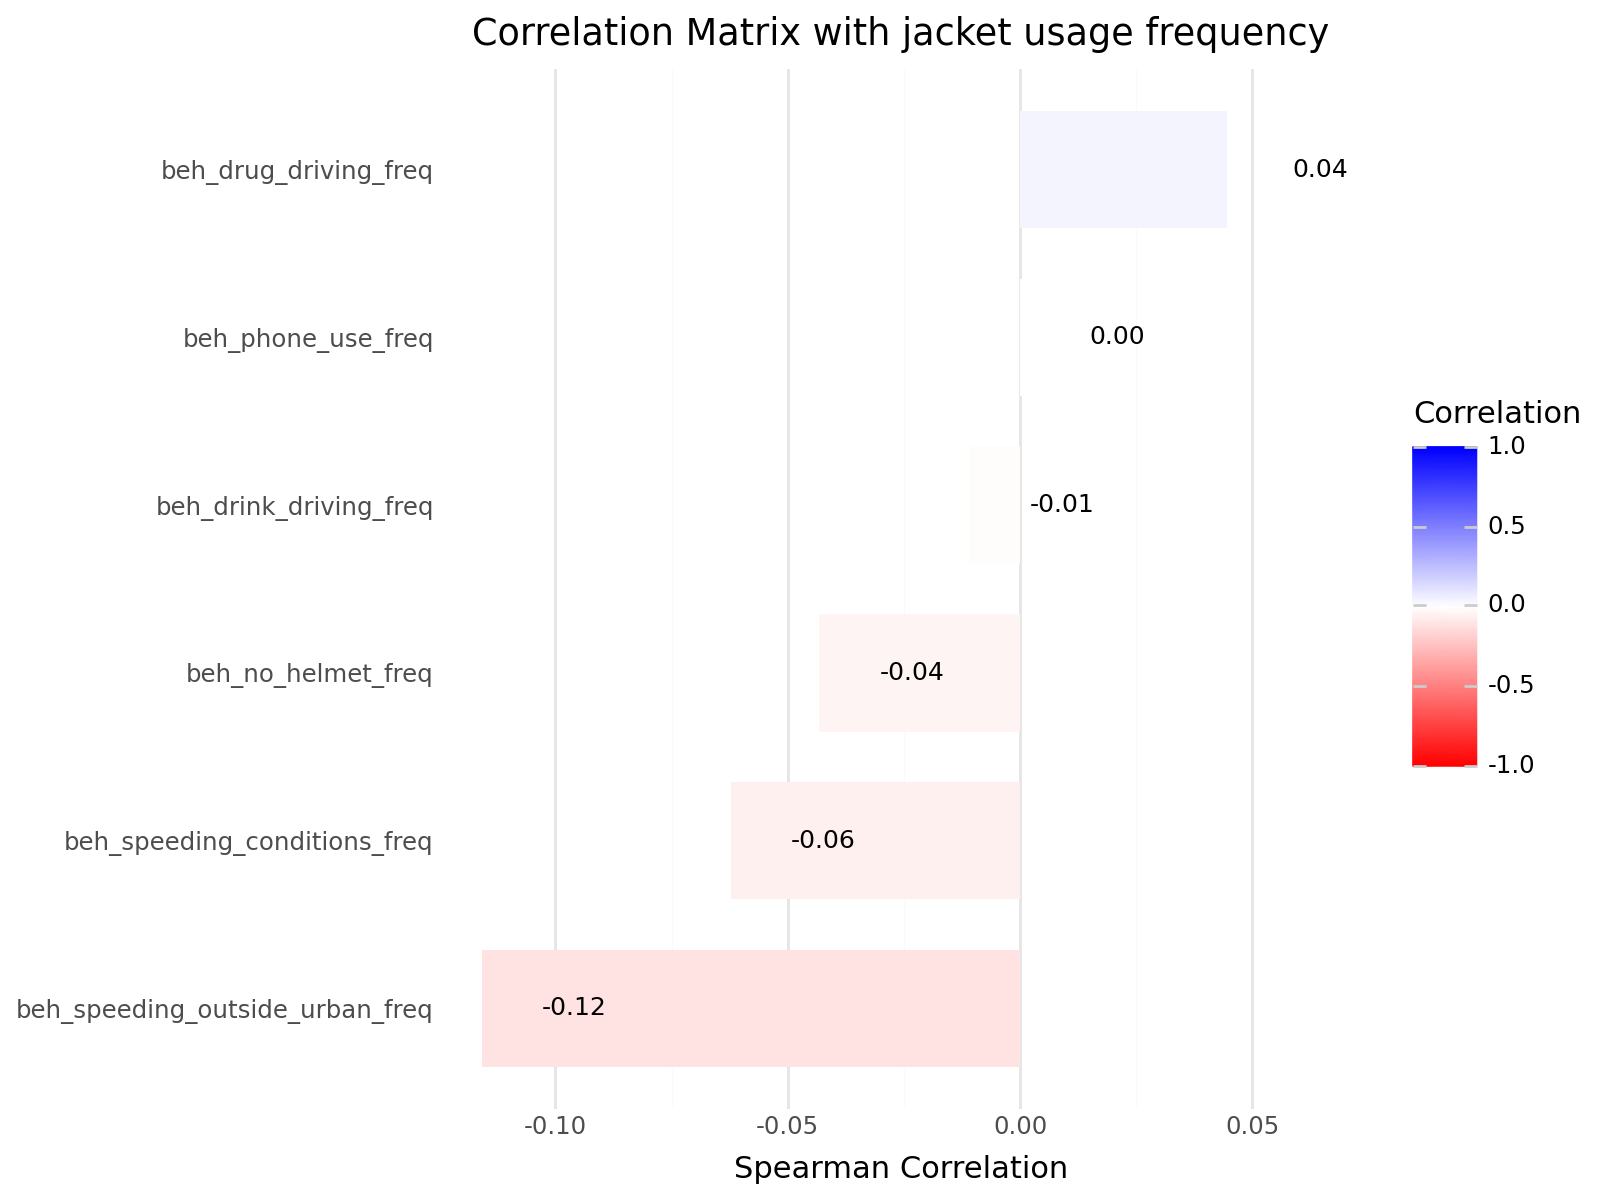

In [30]:
plot_lower_triangle_heatmap(motocycle_df, columns=p7_vars + [target_var], title="Correlation Matrix", method='spearman')
plot_target_correlation(motocycle_df,  target_col=target_var, feature_cols=p7_vars,  title="Correlation Matrix with jacket usage frequency")


### Jacket vs barriers (q14)

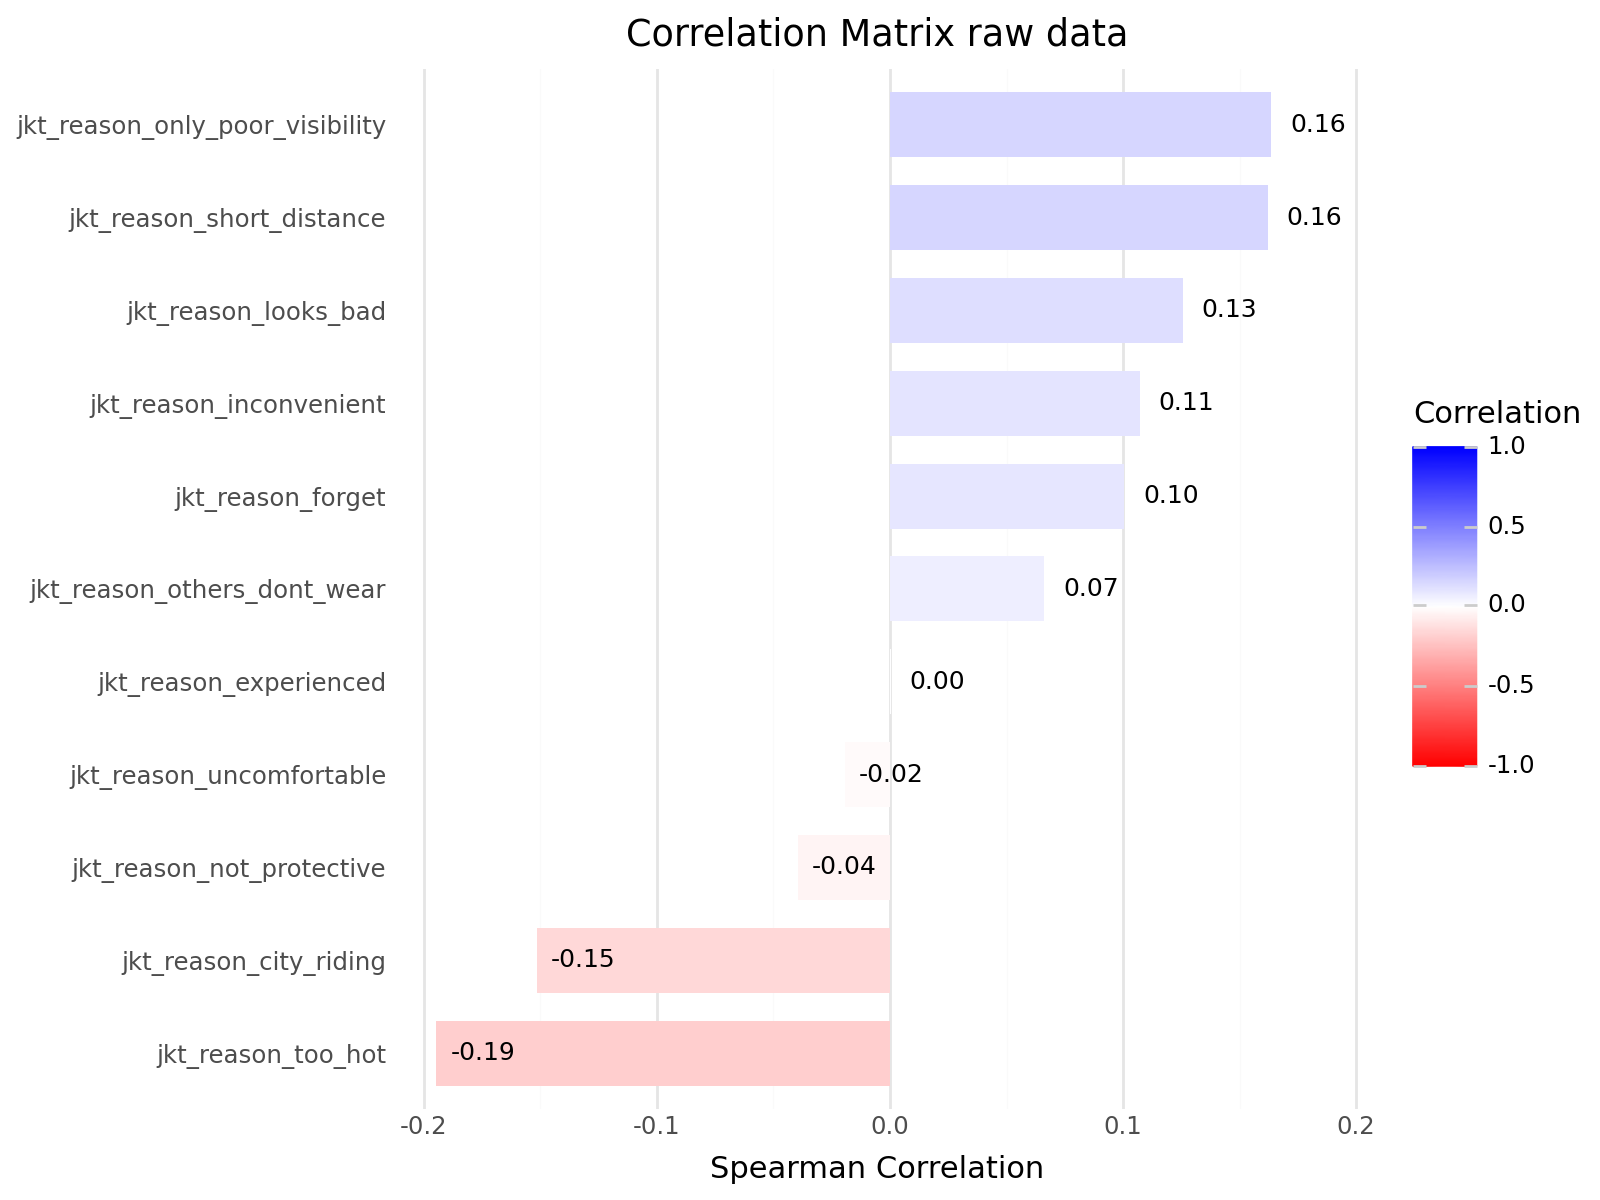

In [24]:
# New logic is P13_inv < 4 (Not Always)
subset_df = motocycle_df[motocycle_df[target_var] != "4"].copy()

plot_lower_triangle_heatmap(subset_df, columns=p14_vars + [target_var], title="Correlation Matrix", method='spearman')
plot_target_correlation(subset_df,  target_col=target_var, feature_cols=p14_vars,  title="Correlation Matrix raw data")



### Jacket vs barriers (q14) Impute barriers when usage=always

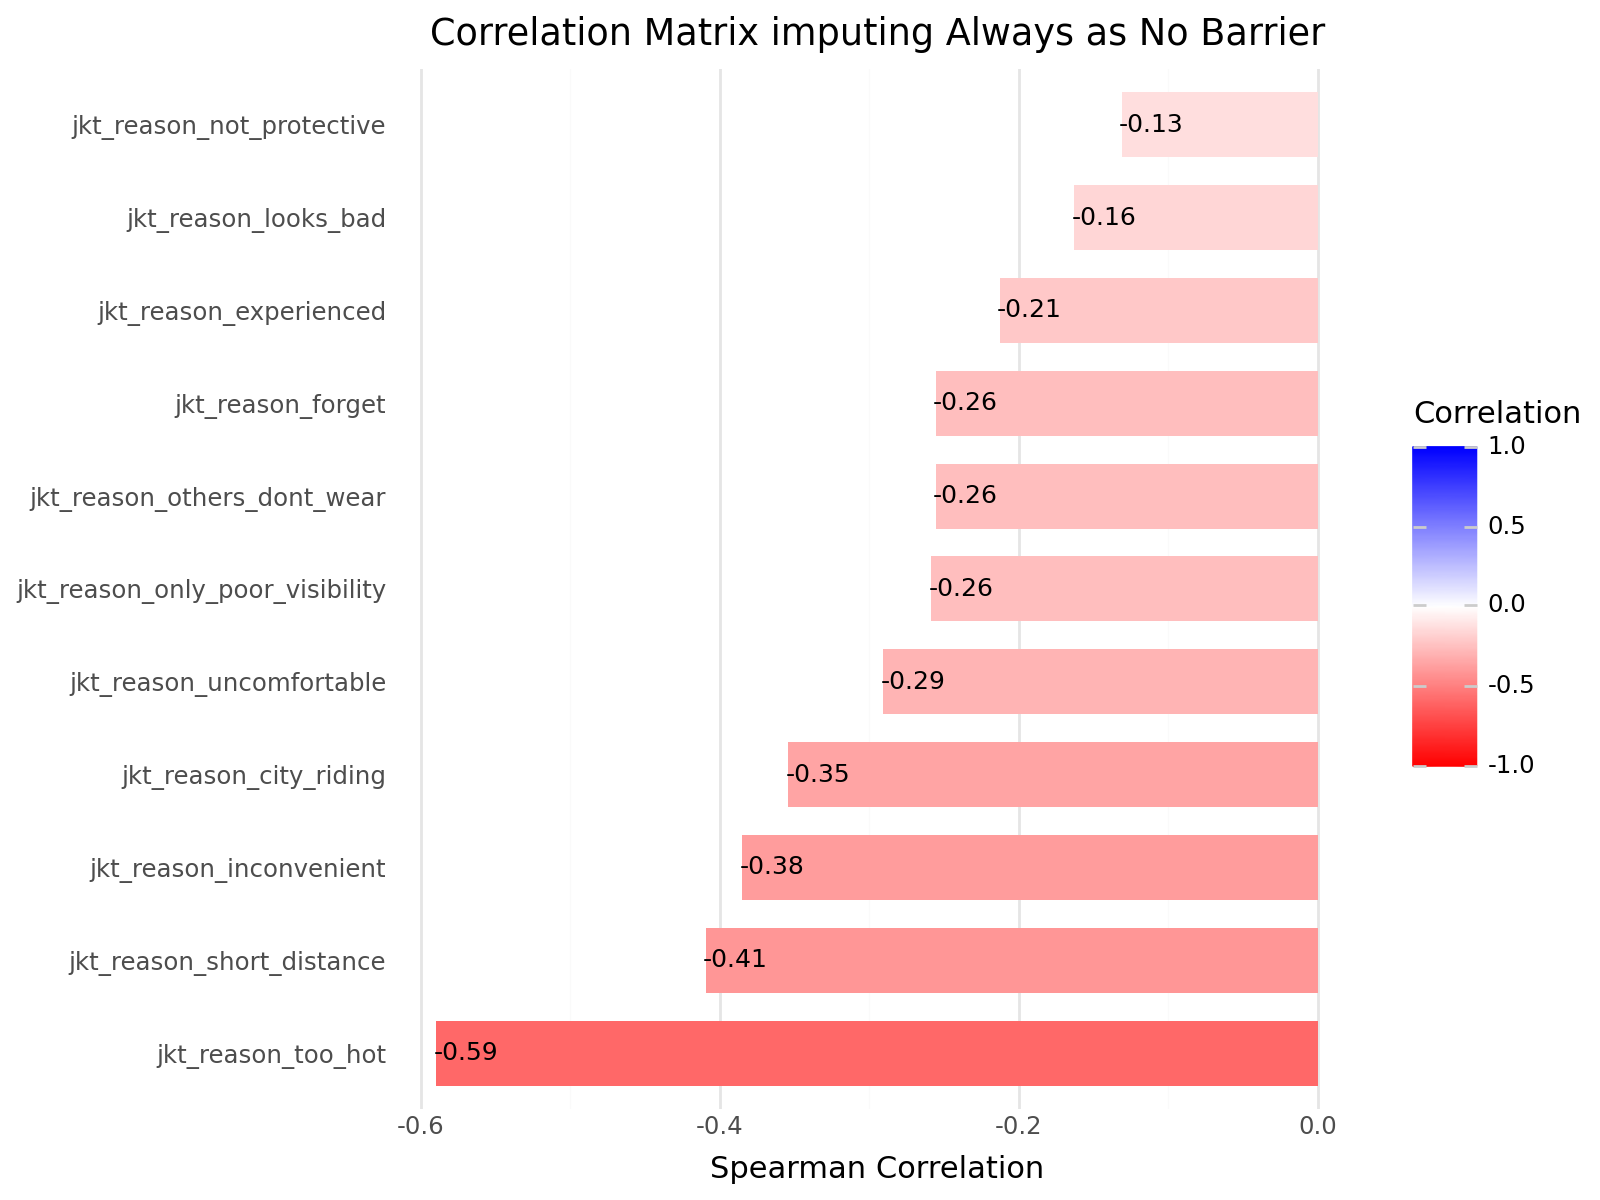

In [25]:
# Create a copy to avoid modifying original df
imputed_df = motocycle_df.copy()

# Apply condition and set p14_vars to 0
imputed_df.loc[imputed_df[target_var] == 4, p14_vars] = 0

plot_lower_triangle_heatmap(imputed_df, columns=p14_vars + [target_var], title="Correlation Matrix", method='spearman')

plot_target_correlation(imputed_df,  target_col=target_var, feature_cols=p14_vars,  title="Correlation Matrix imputing Always as No Barrier")



### Jacket vs statements (q15)

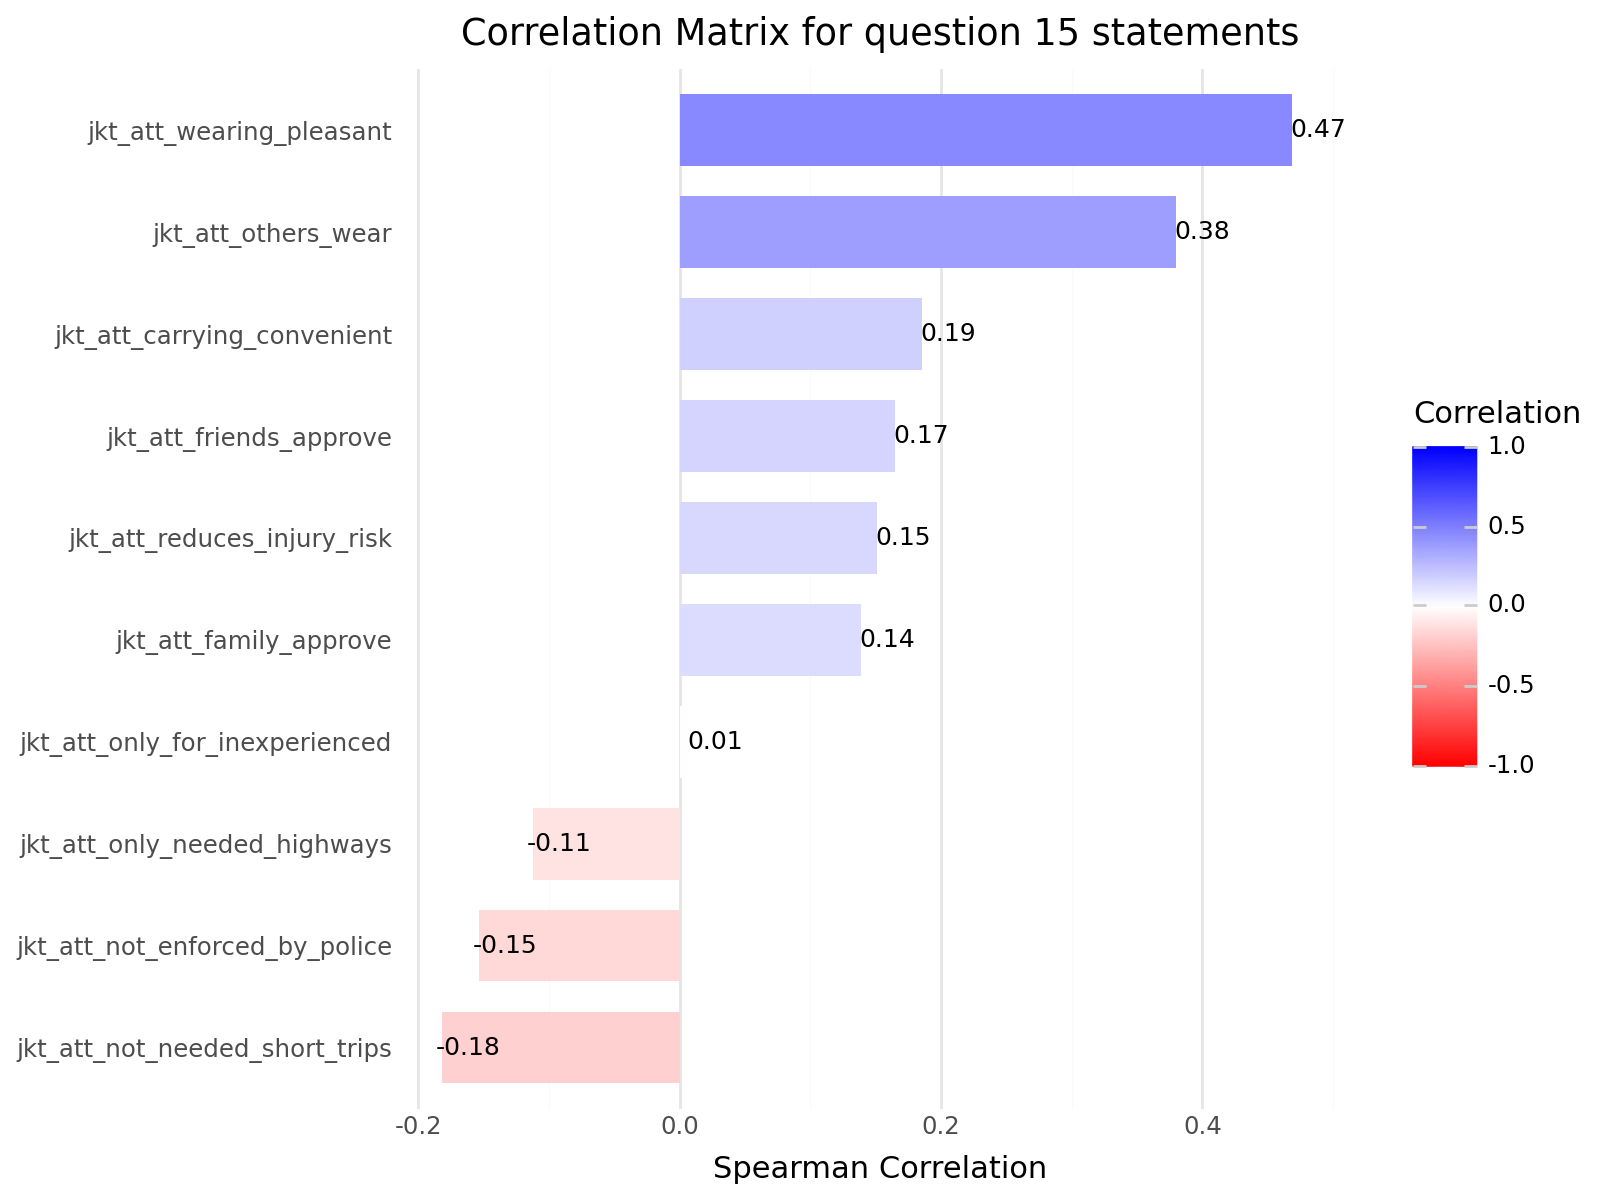

In [10]:
plot_lower_triangle_heatmap(motocycle_df, columns=p15_vars + [target_var], title="Correlation Matrix", method='spearman')

plot_target_correlation(motocycle_df,  target_col=target_var, feature_cols=p15_vars,  title="Correlation Matrix for question 15 statements")

## Leg protector

In [17]:
# Assuming your target variable is 'P13_jkt_usage_freq'
target_var = "P17_leg_usage_freq"

### Leg protector vs behaviour (q7)

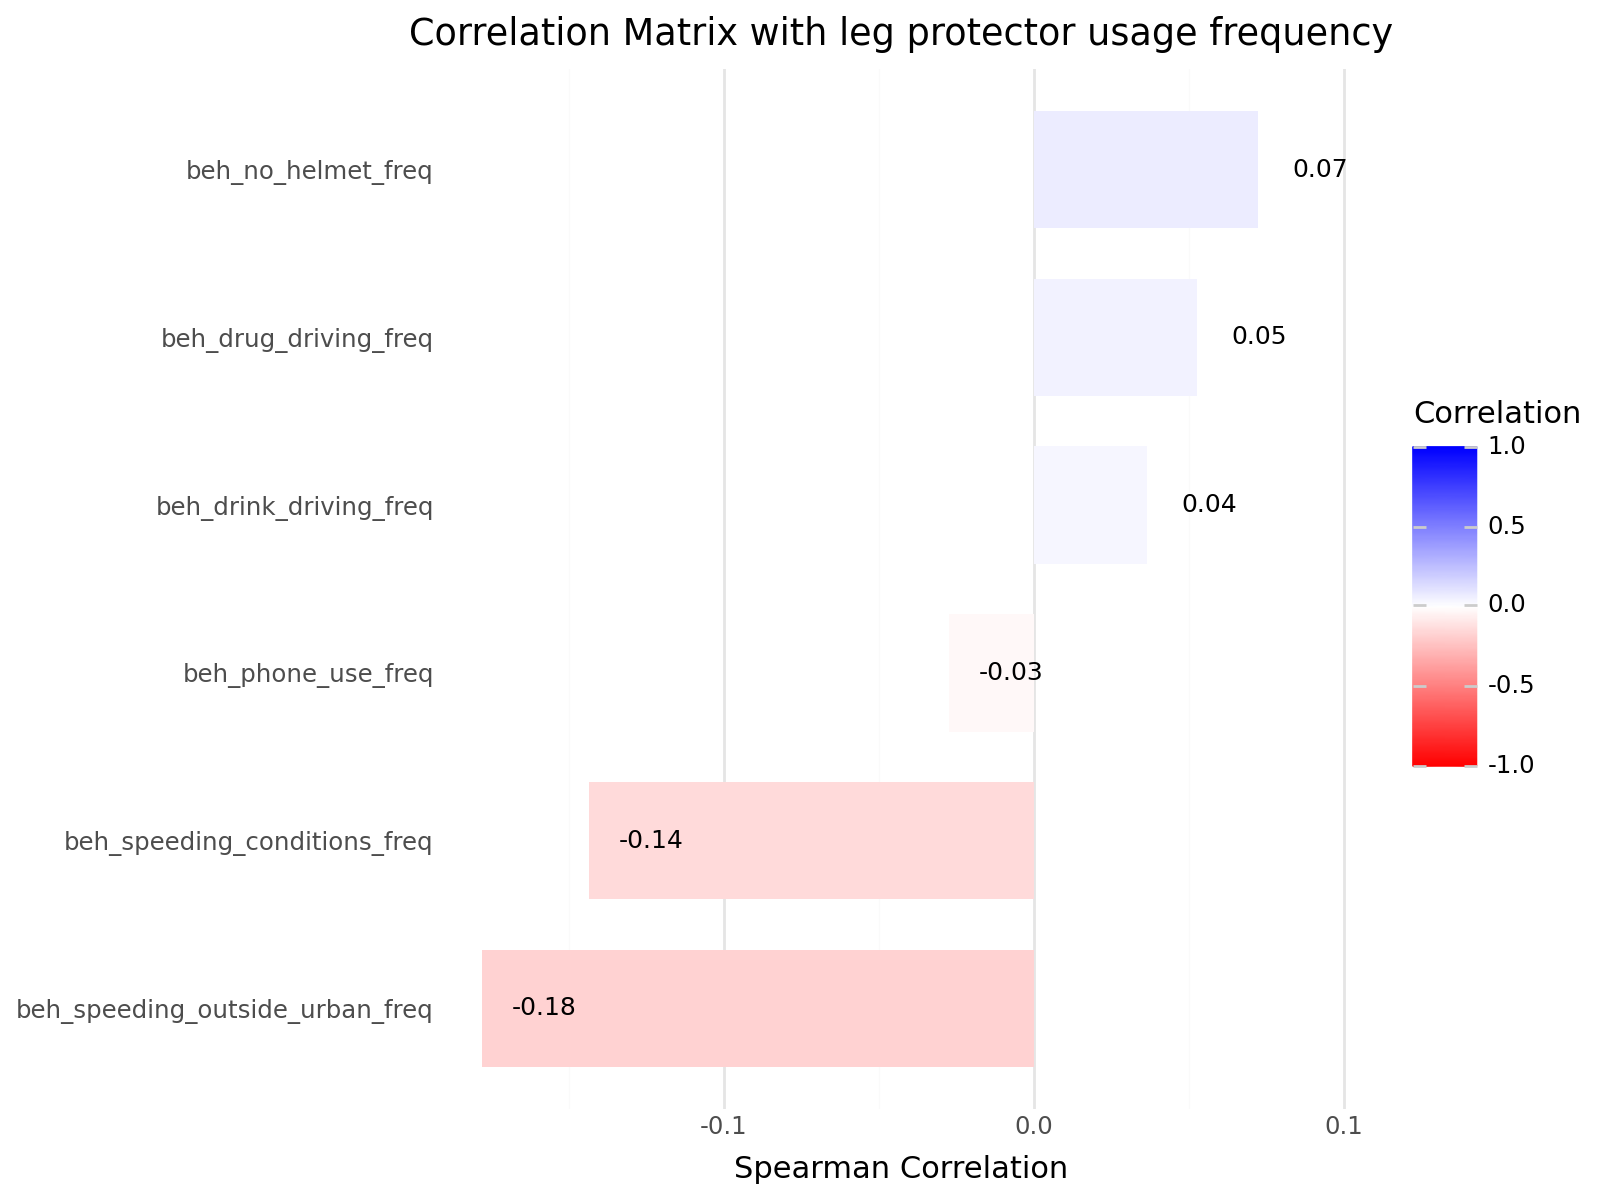

In [27]:
plot_lower_triangle_heatmap(motocycle_df, columns=p7_vars + [target_var], title="Correlation Matrix", method='spearman')
plot_target_correlation(motocycle_df,  target_col=target_var, feature_cols=p7_vars,  title="Correlation Matrix with leg protector usage frequency")


### Leg protector vs barriers (q14)

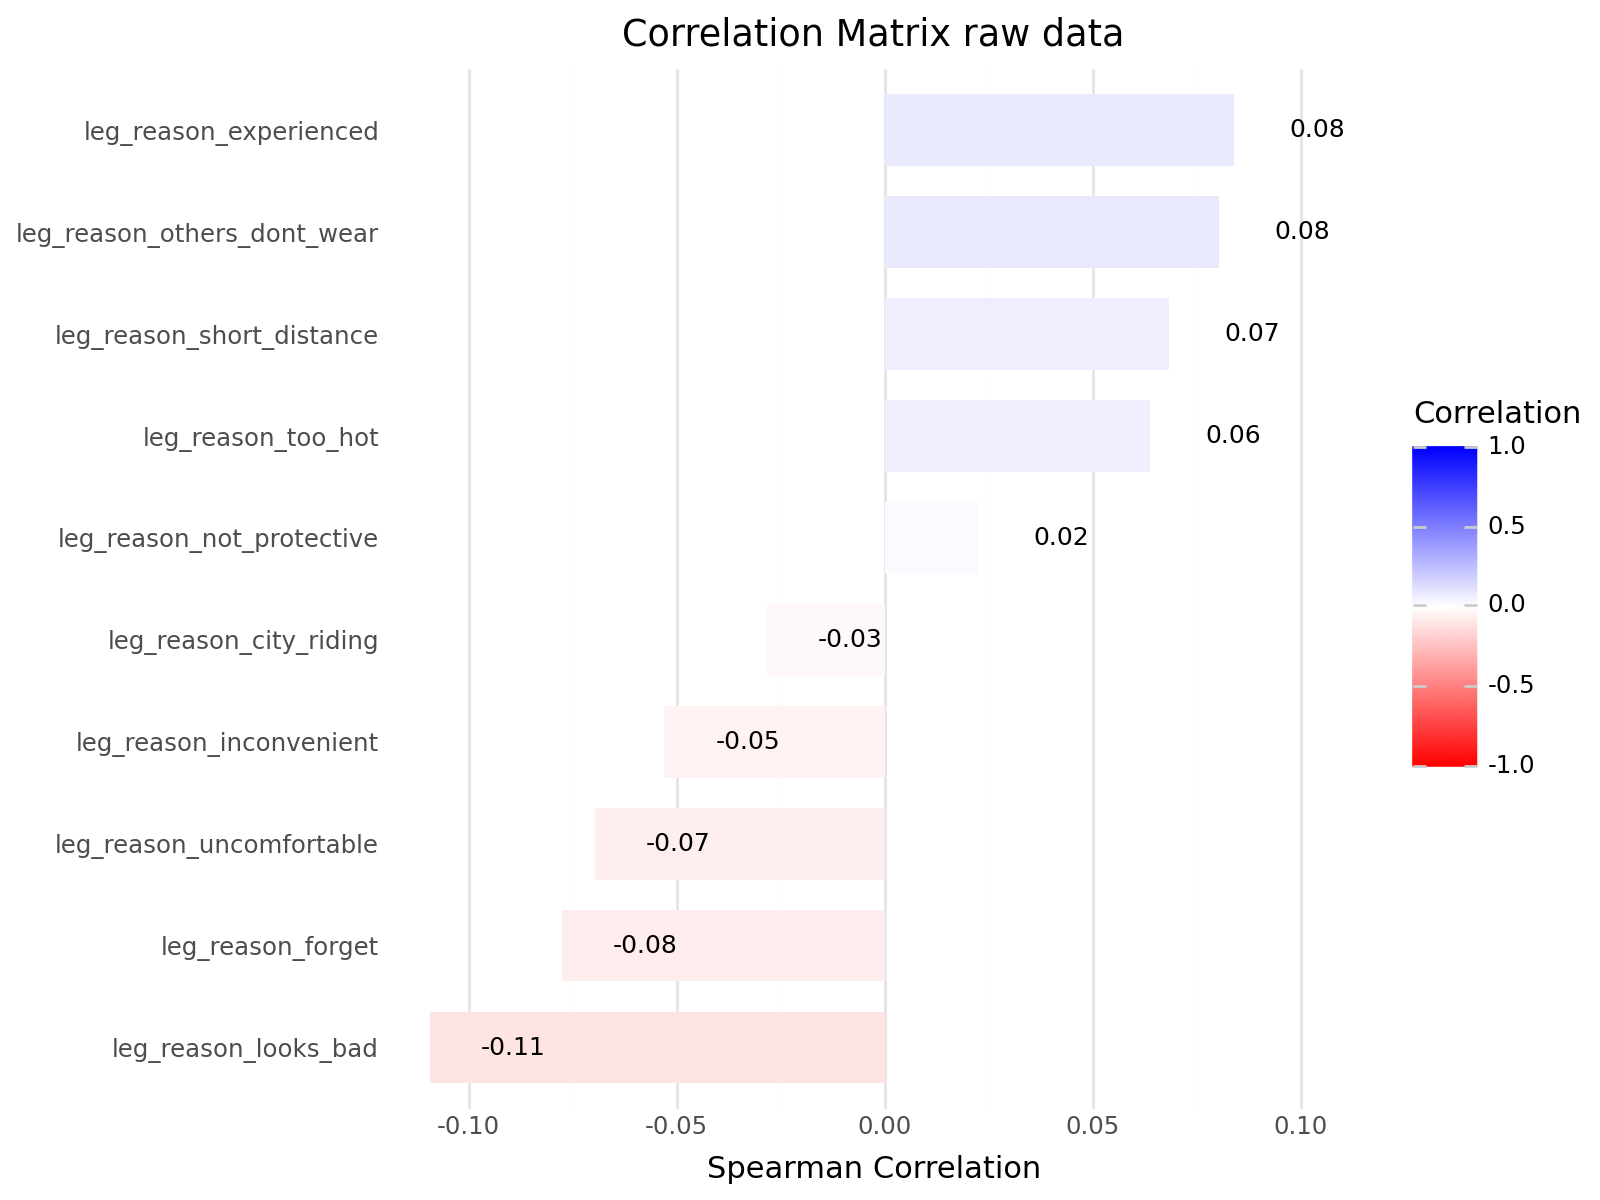

In [20]:
# New logic is P13_inv < 4 (Not Always)
subset_df = motocycle_df[motocycle_df[target_var] != "4"].copy()

plot_lower_triangle_heatmap(subset_df, columns=p18_vars + [target_var], title="Correlation Matrix", method='spearman')
plot_target_correlation(subset_df,  target_col=target_var, feature_cols=p18_vars,  title="Correlation Matrix raw data")



### Leg protector vs barriers (q14) Impute barriers when usage=always

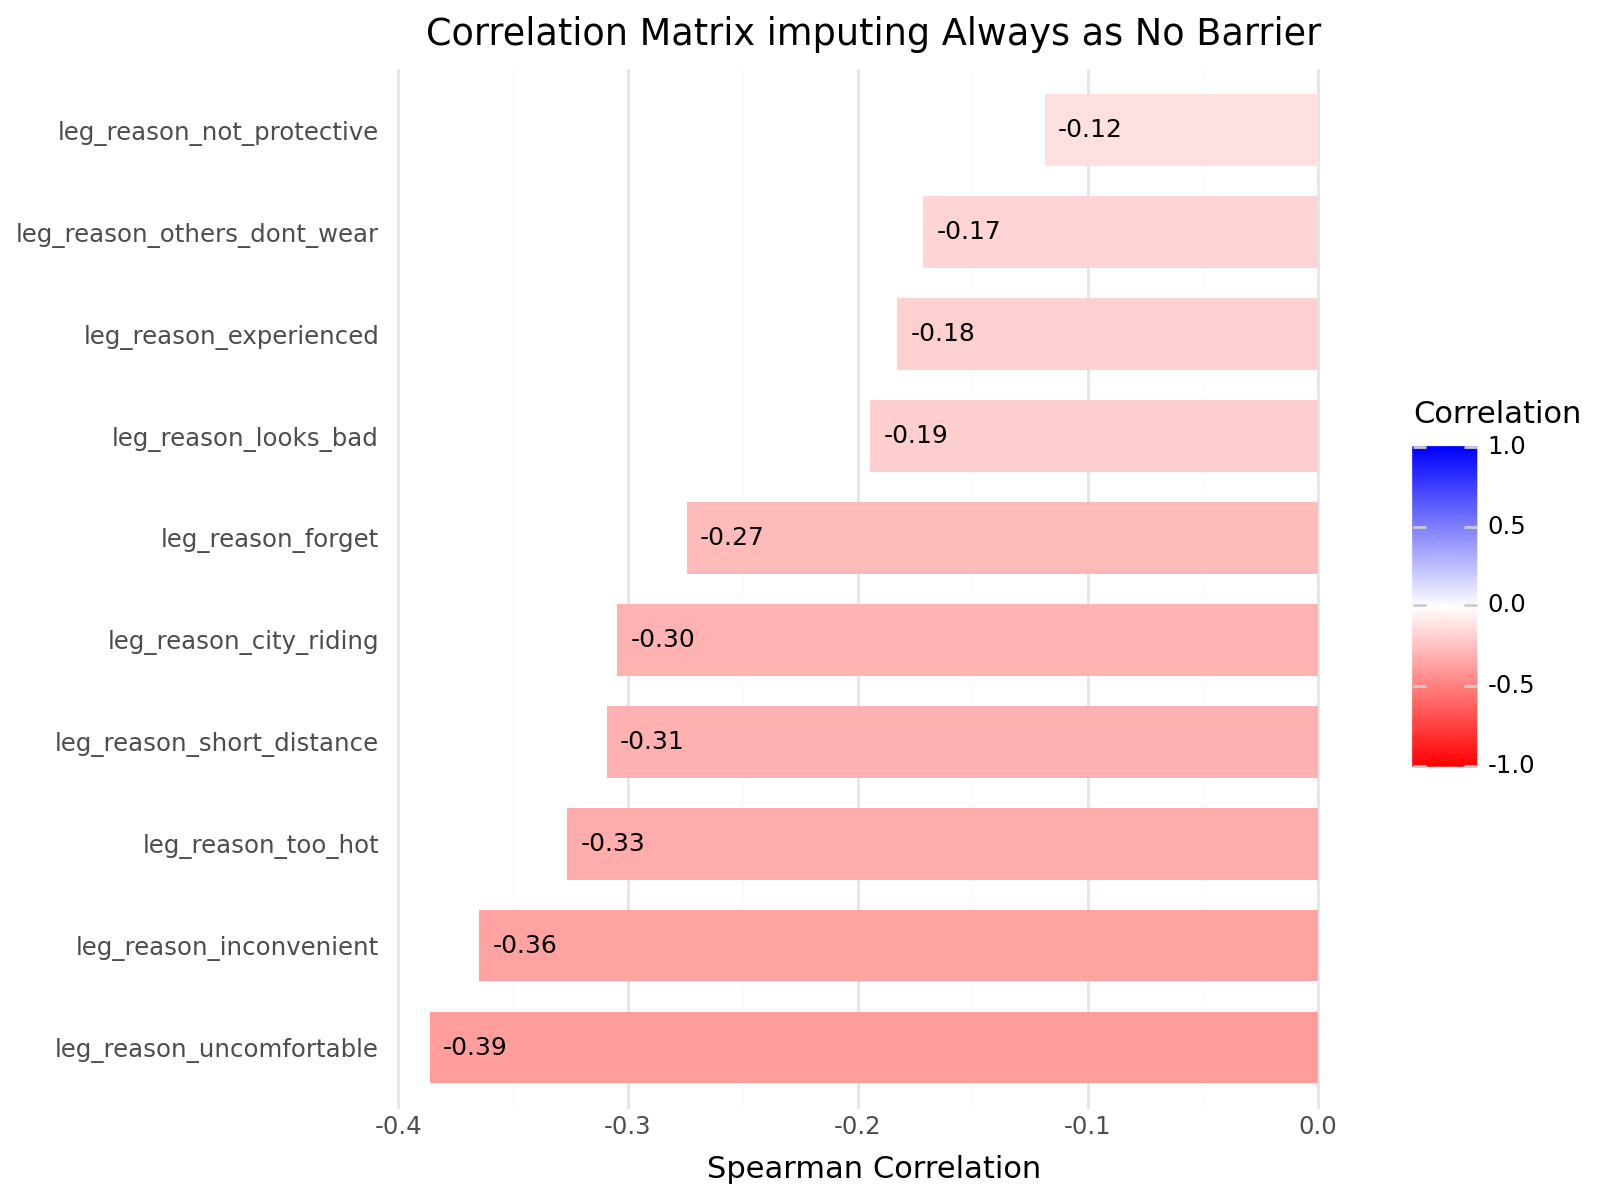

In [21]:
# Create a copy to avoid modifying original df
imputed_df = motocycle_df.copy()

# Apply condition and set p14_vars to 0
imputed_df.loc[imputed_df[target_var] == 4, p18_vars] = 0

plot_lower_triangle_heatmap(imputed_df, columns=p18_vars + [target_var], title="Correlation Matrix", method='spearman')

plot_target_correlation(imputed_df,  target_col=target_var, feature_cols=p18_vars,  title="Correlation Matrix imputing Always as No Barrier")



### Leg protector vs statements (q15)

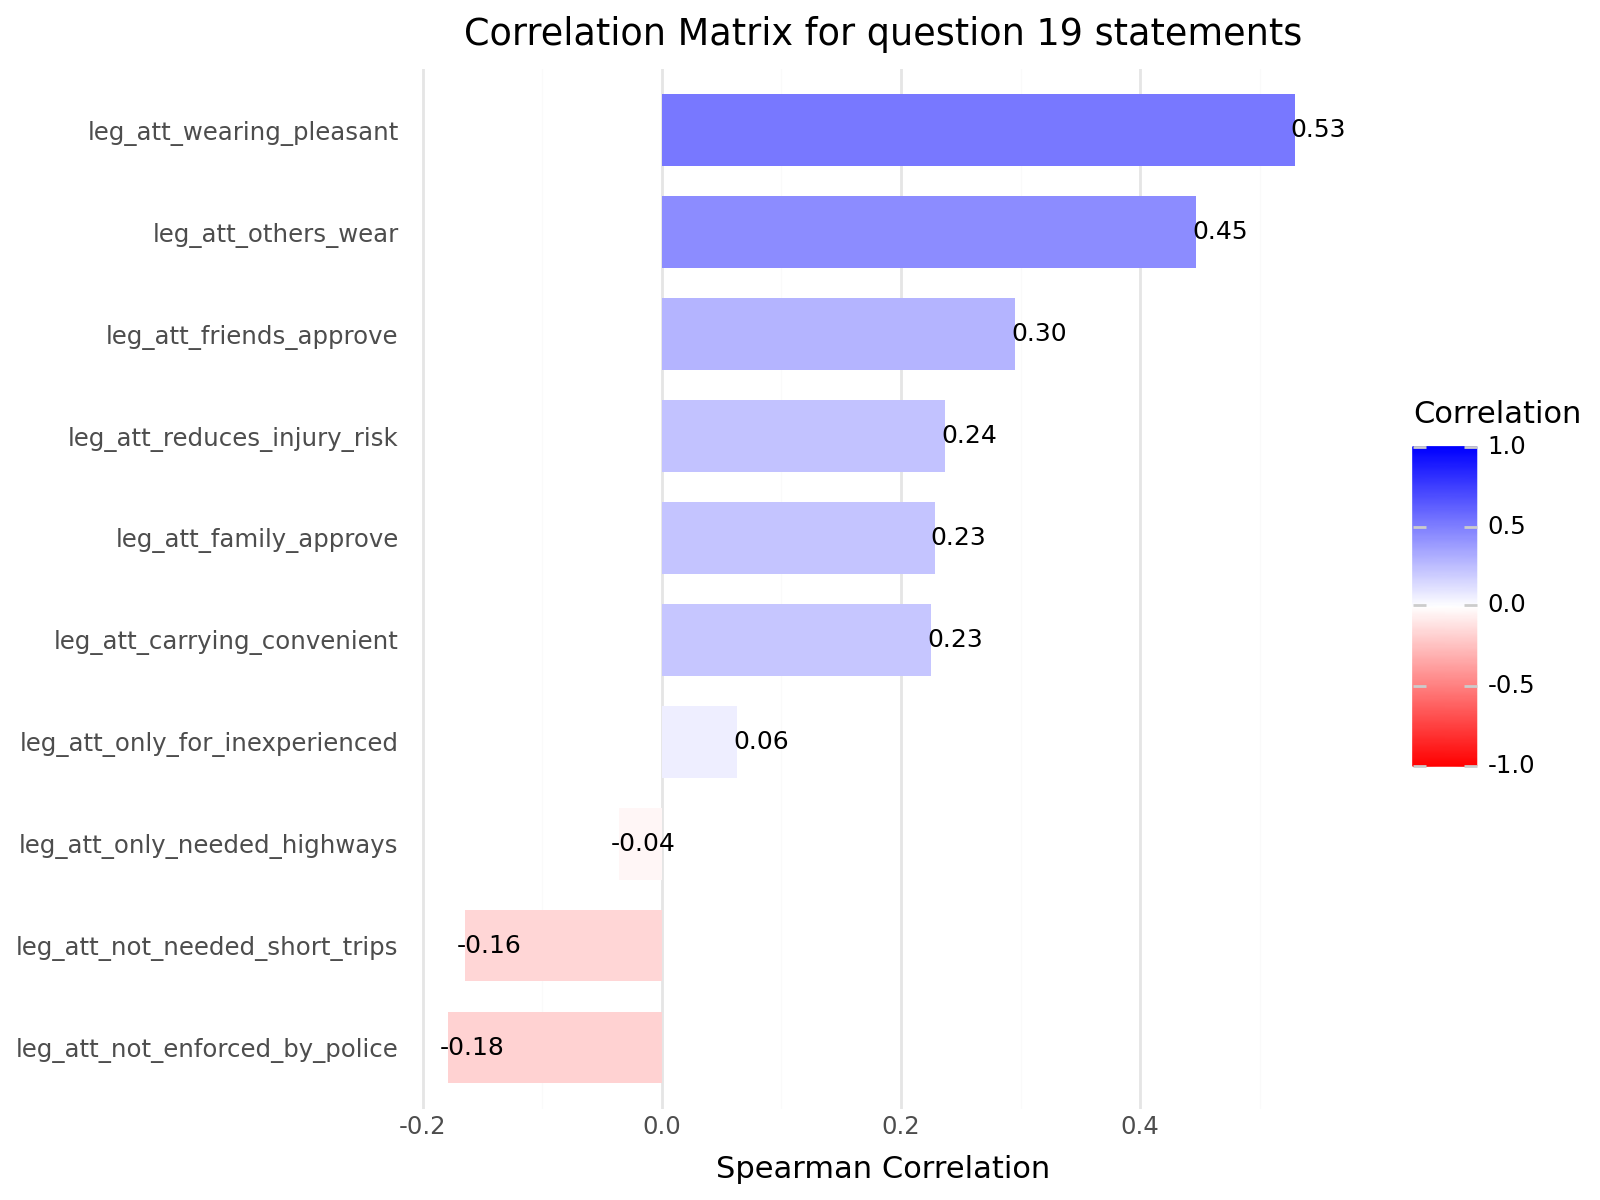

In [22]:
plot_lower_triangle_heatmap(motocycle_df, columns=p19_vars + [target_var], title="Correlation Matrix", method='spearman')

plot_target_correlation(motocycle_df,  target_col=target_var, feature_cols=p19_vars,  title="Correlation Matrix for question 19 statements")

# Save data

In [46]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

